# AMHS 반송 시뮬레이션 & 디스패칭 알고리즘 비교

`amhs/`에 구현한 SimPy 이산사건 시뮬레이션으로, OHT 차량이 8개 공정 스테이션 사이를 오가며 FOUP(웨이퍼 로트)을 반송하는 상황을 재현한다.

각 스테이션의 설비는 동시에 1개 FOUP만 처리할 수 있고(`simpy.Resource(capacity=1)`), 그 설비의 **대기열 길이가 곧 스토커(입력 버퍼) 점유량**이다. 대기열이 `stocker_capacity`만큼 차 있으면 OHT는 드롭오프를 못 하고 FOUP을 실은 채 기다린다 — 그동안 방금 공정을 마친 업스트림 설비도 다음 FOUP을 못 받아 묶인다(**back-pressure**). 이 노트북은 다섯 가지를 확인한다:

1. **디스패칭 정책 비교** — 최근접 / FCFS / 구역기반 / (모델 있으면) 예측 기반
2. **차량 대수 민감도** — 차량을 늘리면 반송 시간이 어떻게 줄어드는지
3. **스토커 용량 민감도** — 버퍼 크기가 정체와 평균 반송 시간에 주는 영향
4. **혼잡 시계열** — 큐 길이가 시간에 따라 어떻게 쌓이고 빠지는지
5. **예지보전 피드백** — 차량이 주기적으로 고장 나 운행이 중단되면 반송 시간이 어떻게 나빠지는지

정책/파라미터를 제외한 모든 조건(스테이션 처리시간 분포, FOUP 도착 간격, 난수 시드)은 동일하게 고정해 비교가 공정하도록 했다. **완료율이 1.0이 아닌 시나리오는 신뢰하지 않는다** —
차량이 너무 적으면 이 시스템은 대기행렬 이론에서 말하는 '불안정 상태'(도착률이 처리율을 넘어서는 상태)가 되어 큐가 무한정 쌓인다. 그런 경우 평균은 의미가 없으므로, 아래 실험 파라미터는 모두 완료율 1.0을 먼저 확인한 뒤 골랐다.

In [1]:
import sys
from pathlib import Path

ROOT_DIR = Path.cwd().parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

from amhs import (
    STATION_ORDER, STATIONS,
    run_simulation, nearest_vehicle_dispatch, fcfs_dispatch, zone_based_dispatch,
    make_predictive_dispatch, delay_model_available,
    make_maintenance_process, pm_model_available,
)

MODELS_DIR = ROOT_DIR / "models"
MODELS_DIR.mkdir(exist_ok=True)

print("stations (반송 순서):")
for name in STATION_ORDER:
    s = STATIONS[name]
    print(f"  {s.index}. {s.name_ko:>8} ({name}) — 평균 처리시간 {s.process_time_mean_sec:.0f}초")

stations (반송 순서):
  0.   웨이퍼 제조 (wafer_fabrication) — 평균 처리시간 180초
  1.       산화 (oxidation) — 평균 처리시간 195초
  2.       포토 (photolithography) — 평균 처리시간 210초
  3.       식각 (etching) — 평균 처리시간 225초
  4.       증착 (deposition) — 평균 처리시간 240초
  5.    금속 배선 (metallization) — 평균 처리시간 255초
  6.      EDS (eds) — 평균 처리시간 270초
  7.      패키징 (packaging) — 평균 처리시간 285초


## 1. 기본 시나리오 (최근접 차량 배정)

차량 5대, FOUP 10개가 각 1바퀴(=7회 스테이션 통과)씩 도는 시나리오. 스토커 용량은 기본값(2).

In [2]:
BASE_PARAMS = dict(n_vehicles=5, n_foups=10, n_laps=1, foup_launch_interval_sec=300.0, seed=42)

baseline = run_simulation(dispatch_policy=nearest_vehicle_dispatch, **BASE_PARAMS)

print(f"완료율: {baseline['completion_rate']:.2%} ({baseline['completed_transports']}/{baseline['expected_transports']})")
print(f"평균 반송 시간: {baseline['avg_cycle_time_sec']:.1f}초")
print(f"P95 반송 시간: {baseline['p95_cycle_time_sec']:.1f}초")
print(f"평균 차량 가동률: {baseline['avg_vehicle_utilization']:.2%}")
print(f"최대 큐 길이: {baseline['max_queue_length']}")
baseline["transport_log"].head()

완료율: 100.00% (70/70)
평균 반송 시간: 91.4초
P95 반송 시간: 197.8초
평균 차량 가동률: 4.73%
최대 큐 길이: 4


,foup_id,from,to,requested_at,completed_at,cycle_time_sec,vehicle_id
0,0,wafer_fabrication,oxidation,159.200318,211.563954,52.363636,0
1,0,oxidation,photolithography,421.572978,473.936615,52.363636,0
2,0,photolithography,etching,702.747909,755.111545,52.363636,0
3,0,etching,deposition,973.786693,1026.150330,52.363636,0
4,1,wafer_fabrication,oxidation,875.218991,1073.037173,197.818182,4


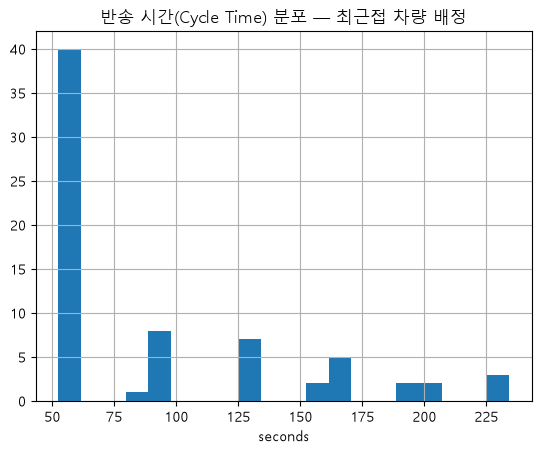

In [3]:
baseline["transport_log"]["cycle_time_sec"].hist(bins=20)
plt.title("반송 시간(Cycle Time) 분포 — 최근접 차량 배정")
plt.xlabel("seconds")
plt.show()

## 2. 디스패칭 정책 비교

동일한 `BASE_PARAMS`로 정책만 바꿔 실행한다. 지연 예측 모델(노트북 08)이 학습돼 있으면 **예측 기반 적응형 디스패칭**도 같이 비교한다 — 이 정책은 실시간으로 지연을 예측해, 혼잡하다고 판단되면 구역기반으로, 아니면 최근접으로 전환한다.

In [4]:
policies = {
    "nearest_vehicle": nearest_vehicle_dispatch,
    "fcfs": fcfs_dispatch,
    "zone_based": zone_based_dispatch,
}
if delay_model_available():
    policies["predictive"] = make_predictive_dispatch(
        n_vehicles=BASE_PARAMS["n_vehicles"], launch_interval_sec=BASE_PARAMS["foup_launch_interval_sec"],
    )
else:
    print("지연 예측 모델이 없어 predictive 정책은 건너뜀 (notebooks/08 먼저 실행)")

policy_results = {}
rows = []
for name, policy in policies.items():
    result = run_simulation(dispatch_policy=policy, **BASE_PARAMS)
    policy_results[name] = result
    rows.append({
        "policy": name,
        "completion_rate": result["completion_rate"],
        "avg_cycle_time_sec": round(result["avg_cycle_time_sec"], 1),
        "p95_cycle_time_sec": round(result["p95_cycle_time_sec"], 1),
        "avg_vehicle_utilization": round(result["avg_vehicle_utilization"], 4),
        "max_queue_length": result["max_queue_length"],
    })

policy_comparison = pd.DataFrame(rows)
policy_comparison

,policy,completion_rate,avg_cycle_time_sec,p95_cycle_time_sec,avg_vehicle_utilization,max_queue_length
0,nearest_vehicle,1.0,91.4,197.8,0.0473,4
1,fcfs,1.0,175.1,306.9,0.0894,4
2,zone_based,1.0,115.7,270.5,0.0600,3
3,predictive,1.0,91.4,197.8,0.0473,4


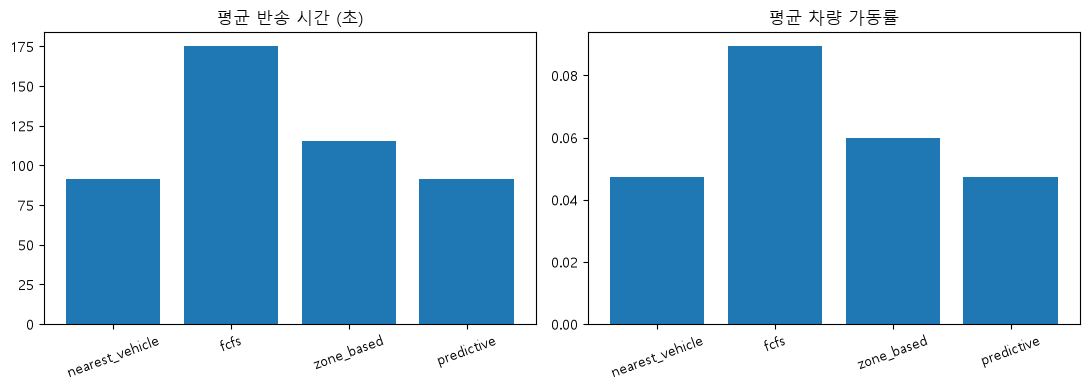

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(policy_comparison["policy"], policy_comparison["avg_cycle_time_sec"])
axes[0].set_title("평균 반송 시간 (초)")
axes[0].tick_params(axis="x", rotation=20)
axes[1].bar(policy_comparison["policy"], policy_comparison["avg_vehicle_utilization"])
axes[1].set_title("평균 차량 가동률")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## 3. 차량 대수 민감도

최근접 차량 배정 정책으로 고정하고, 차량 대수만 2~10대로 바꿔가며 평균 반송 시간이 어떻게 줄어드는지 본다.

In [6]:
vehicle_counts = [2, 3, 4, 5, 6, 8, 10]
sensitivity_rows = []
for n in vehicle_counts:
    result = run_simulation(
        n_vehicles=n, n_foups=10, n_laps=1, foup_launch_interval_sec=300.0, seed=42,
        dispatch_policy=nearest_vehicle_dispatch,
    )
    sensitivity_rows.append({
        "n_vehicles": n,
        "completion_rate": result["completion_rate"],
        "avg_cycle_time_sec": result["avg_cycle_time_sec"],
        "avg_vehicle_utilization": result["avg_vehicle_utilization"],
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df

,n_vehicles,completion_rate,avg_cycle_time_sec,avg_vehicle_utilization
0,2,1.0,239.324593,0.196500
1,3,1.0,153.577437,0.122467
2,4,1.0,102.419481,0.066250
3,5,1.0,91.353247,0.047340
4,6,1.0,75.740260,0.032717
5,8,1.0,64.831169,0.021012
6,10,1.0,64.311688,0.016670


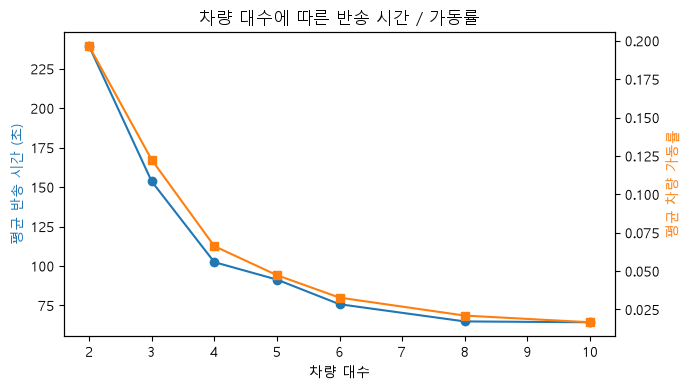

In [7]:
fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(sensitivity_df["n_vehicles"], sensitivity_df["avg_cycle_time_sec"], marker="o", color="tab:blue")
ax1.set_xlabel("차량 대수")
ax1.set_ylabel("평균 반송 시간 (초)", color="tab:blue")

ax2 = ax1.twinx()
ax2.plot(sensitivity_df["n_vehicles"], sensitivity_df["avg_vehicle_utilization"], marker="s", color="tab:orange")
ax2.set_ylabel("평균 차량 가동률", color="tab:orange")

plt.title("차량 대수에 따른 반송 시간 / 가동률")
plt.tight_layout()
plt.show()

## 4. 스토커 용량 민감도 & back-pressure

차량 대수는 고정(4대)하고 스토커 용량만 1~5로 바꿔본다. 큐 길이의 최댓값은 정의상 용량이 클수록 더 크게 자랄 '여유'가 있으므로 큰 용량 쪽이 커지는 게 당연하다 — 여기서 진짜 보려는 것은 **평균 반송 시간**이다: 스토커가 작으면 back-pressure가 일찍 걸려 시스템에 떠 있는 FOUP 수(WIP) 자체가 줄어드는데, 이게 오히려 개별 FOUP의 평균 반송 시간을 짧게 만드는지 확인한다(린 생산의 '적은 WIP가 짧은 리드타임을 만든다'는 원리와 같은 방향).

In [8]:
stocker_caps = [1, 2, 3, 5]
stocker_rows = []
for cap in stocker_caps:
    result = run_simulation(
        n_vehicles=4, n_foups=10, n_laps=1, foup_launch_interval_sec=300.0,
        stocker_capacity=cap, dispatch_policy=nearest_vehicle_dispatch, seed=42,
    )
    stocker_rows.append({
        "stocker_capacity": cap,
        "completion_rate": result["completion_rate"],
        "avg_cycle_time_sec": round(result["avg_cycle_time_sec"], 1),
        "max_queue_length": result["max_queue_length"],
    })

stocker_df = pd.DataFrame(stocker_rows)
stocker_df

,stocker_capacity,completion_rate,avg_cycle_time_sec,max_queue_length
0,1,1.0,98.6,3
1,2,1.0,102.4,4
2,3,1.0,102.4,4
3,5,1.0,102.4,4


## 5. 혼잡 시계열

기본 시나리오(1절)의 `congestion_log`로, 전체 스테이션 평균 큐 길이가 시간에 따라 어떻게 변하는지 본다.

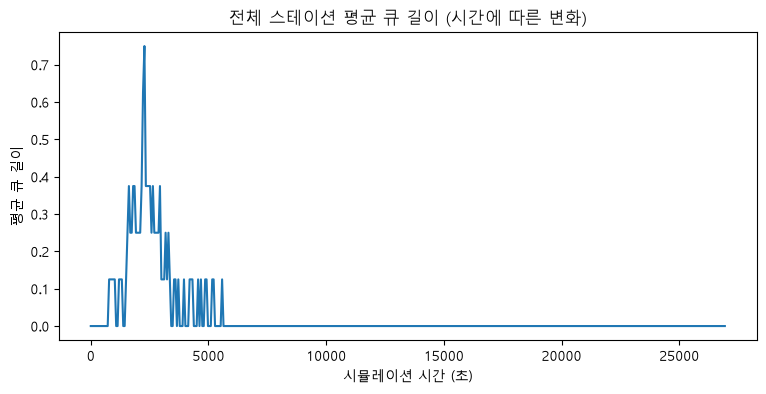

In [9]:
congestion = baseline["congestion_log"]
avg_queue_over_time = congestion.groupby("time")["queue_length"].mean()

plt.figure(figsize=(9, 4))
plt.plot(avg_queue_over_time.index, avg_queue_over_time.values)
plt.title("전체 스테이션 평균 큐 길이 (시간에 따른 변화)")
plt.xlabel("시뮬레이션 시간 (초)")
plt.ylabel("평균 큐 길이")
plt.show()

## 6. 예지보전 피드백

노트북 09의 IF+XGBoost 예지보전 모델이 학습돼 있으면, 차량이 주기적으로 고장 나 일정 시간 운행 중단되는 상황을 시뮬레이션에 반영해 본다. 단일 시드로 비교하면 예지보전 프로세스 자체가 추가로 소비하는 난수 때문에 이후 무작위성이 달라져(같은 시드라도 다른 시뮬레이션이 되어) 비교가 왜곡될 수 있어, **여러 시드에 걸쳐 평균**을 내서 비교한다.

In [10]:
if pm_model_available():
    N_SEEDS = 15
    no_maint_cycles, with_maint_cycles = [], []
    total_events = 0
    for seed in range(N_SEEDS):
        r_no = run_simulation(dispatch_policy=nearest_vehicle_dispatch, seed=seed,
                               n_vehicles=5, n_foups=10, n_laps=1, foup_launch_interval_sec=300.0)
        no_maint_cycles.append(r_no["avg_cycle_time_sec"])

        log = []
        maint = make_maintenance_process(check_interval_sec=1800.0, downtime_sec=1200.0, anomaly_ratio=0.1, maintenance_log=log)
        r_yes = run_simulation(dispatch_policy=nearest_vehicle_dispatch, maintenance_process=maint, seed=seed,
                                n_vehicles=5, n_foups=10, n_laps=1, foup_launch_interval_sec=300.0)
        with_maint_cycles.append(r_yes["avg_cycle_time_sec"])
        total_events += len(log)

    pm_comparison = pd.DataFrame([
        {"scenario": "예지보전 없음(고장 무시)", "avg_cycle_time_sec": round(np.mean(no_maint_cycles), 1)},
        {"scenario": "예지보전 피드백 적용", "avg_cycle_time_sec": round(np.mean(with_maint_cycles), 1)},
    ])
    print(f"{N_SEEDS}개 시드 평균, 총 고장 이벤트 {total_events}건")
    pm_comparison
else:
    print("예지보전 모델이 없어 이 절은 건너뜀 (notebooks/09 먼저 실행)")
    pm_comparison = None

15개 시드 평균, 총 고장 이벤트 222건


## 7. 결과 저장

In [11]:
policy_comparison.to_csv(MODELS_DIR / "amhs_dispatch_policy_comparison.csv", index=False)
sensitivity_df.to_csv(MODELS_DIR / "amhs_vehicle_sensitivity.csv", index=False)
stocker_df.to_csv(MODELS_DIR / "amhs_stocker_sensitivity.csv", index=False)
baseline["transport_log"].to_csv(MODELS_DIR / "amhs_baseline_transport_log.csv", index=False)
if pm_comparison is not None:
    pm_comparison.to_csv(MODELS_DIR / "amhs_maintenance_comparison.csv", index=False)
print("저장 완료")

저장 완료


## 결론

실행 결과(위 표/그래프)를 보고 채운다. 확인할 것들:

- **디스패칭 정책**: 위치를 고려하는 정책(최근접/구역기반)이 FCFS보다 짧은지. 예측 기반이 이 부하 수준에서 어떻게 판단했는지 — 부하가 낮으면 예측 임계값을 넘지 않아 최근접과 동일하게 행동하는 것도 '올바르게 판단해서 안 바꾼 것'으로 해석할 수 있다.
- **차량 대수**: 어느 지점부터 한계효용이 꺾이는지.
- **스토커 용량**: 최대 큐 길이는 용량이 클수록 커지는 게(정의상) 당연하고, 진짜 봐야 할 건 **평균 반송 시간**이 작은 용량 쪽에서 더 짧게 나오는지 — 그렇다면 '적은 WIP가 짧은 리드타임을 만든다'는 린 생산 원리가 이 시뮬레이션에서도 재현된 것.
- **예지보전**: 여러 시드 평균에서 예지보전 피드백이 있는 쪽의 평균 반송 시간이 일관되게 더 높게(나쁘게) 나오는지 — 도미노 효과가 통계적으로 유의미한 방향으로 드러나는지.